# HomeWork -- WEEK-1 NYC Taxi dataset Duration Prediction

In [1]:
!python -V

Python 3.12.10


1 - 19
2- 42.59
3 - 98
4 - 515
5 - 7.64
6 -

## Import packages

In [2]:
import pandas as pd

In [3]:
import pickle

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

## Download dataset

# Homework - https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

!wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet
!wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet

In [6]:
!wget -P ./data/ https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet
!wget -P ./data/ https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet

--2025-05-11 12:56:19--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 3.164.82.160, 3.164.82.197, 3.164.82.112, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|3.164.82.160|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47673370 (45M) [application/x-www-form-urlencoded]
Saving to: ‘./data/yellow_tripdata_2023-01.parquet.1’

yellow_tripdata_202 100%[===================>]  45.46M   660KB/s    in 62s     

2025-05-11 12:57:22 (747 KB/s) - ‘./data/yellow_tripdata_2023-01.parquet.1’ saved [47673370/47673370]

--2025-05-11 12:57:22--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 3.164.82.160, 3.164.82.40, 3.164.82.197, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|3.164.82.160|:443...

In [7]:
# revanth

df = pd.read_parquet('./data/yellow_tripdata_2023-01.parquet')
df


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.30,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.90,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.90,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.10,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.40,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3066761,2,2023-01-31 23:58:34,2023-02-01 00:12:33,NaN,3.05,NaN,None,107,48,0,15.80,0.00,0.5,3.96,0.0,1.0,23.76,NaN,NaN
3066762,2,2023-01-31 23:31:09,2023-01-31 23:50:36,NaN,5.80,NaN,None,112,75,0,22.43,0.00,0.5,2.64,0.0,1.0,29.07,NaN,NaN
3066763,2,2023-01-31 23:01:05,2023-01-31 23:25:36,NaN,4.67,NaN,None,114,239,0,17.61,0.00,0.5,5.32,0.0,1.0,26.93,NaN,NaN
3066764,2,2023-01-31 23:40:00,2023-01-31 23:53:00,NaN,3.15,NaN,None,230,79,0,18.15,0.00,0.5,4.43,0.0,1.0,26.58,NaN,NaN


In [8]:
df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
print("Q2. What's the standard deviation of the trips duration in January? deviation",df['duration'].std())
original_len=len(df)
print("original_len", original_len )

Q2. What's the standard deviation of the trips duration in January? deviation 42.594351241920904
original_len 3066766


In [9]:
df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)
filtered_len = len(df)
fraction_left = filtered_len / original_len

print(f"Q3. What fraction of the records left after you dropped the outliers? Fraction of records left: {fraction_left:.2f}")
# fraction


Q3. What fraction of the records left after you dropped the outliers? Fraction of records left: 0.98


/tmp/ipykernel_24492/3225758484.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[categorical] = df[categorical].astype(str)


In [10]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [11]:
print ("Q4. What's the dimensionality of this matrix (number of columns)?",X_train)

Q4. What's the dimensionality of this matrix (number of columns)? <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9027519 stored elements and shape (3009173, 516)>
  Coords	Values
  (0, 43)	1.0
  (0, 325)	1.0
  (0, 515)	0.97
  (1, 148)	1.0
  (1, 456)	1.0
  (1, 515)	1.1
  (2, 149)	1.0
  (2, 461)	1.0
  (2, 515)	2.51
  (3, 227)	1.0
  (3, 299)	1.0
  (3, 515)	1.9
  (4, 237)	1.0
  (4, 266)	1.0
  (4, 515)	1.43
  (5, 38)	1.0
  (5, 325)	1.0
  (5, 515)	1.84
  (6, 45)	1.0
  (6, 409)	1.0
  (6, 515)	1.66
  (7, 108)	1.0
  (7, 304)	1.0
  (7, 515)	11.7
  (8, 147)	1.0
  :	:
  (3009164, 515)	9.44
  (3009165, 54)	1.0
  (3009165, 326)	1.0
  (3009165, 515)	0.0
  (3009166, 64)	1.0
  (3009166, 482)	1.0
  (3009166, 515)	0.0
  (3009167, 46)	1.0
  (3009167, 401)	1.0
  (3009167, 515)	0.82
  (3009168, 203)	1.0
  (3009168, 266)	1.0
  (3009168, 515)	3.05
  (3009169, 233)	1.0
  (3009169, 271)	1.0
  (3009169, 515)	5.8
  (3009170, 150)	1.0
  (3009170, 273)	1.0
  (3009170, 515)	4.67
  (3009171, 237)	1.0
 

In [12]:
target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

print("Q5. What's the RMSE on train?",root_mean_squared_error(y_train, y_pred))

Q5. What's the RMSE on train? 7.658559076531841


/tmp/ipykernel_24492/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_24492/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


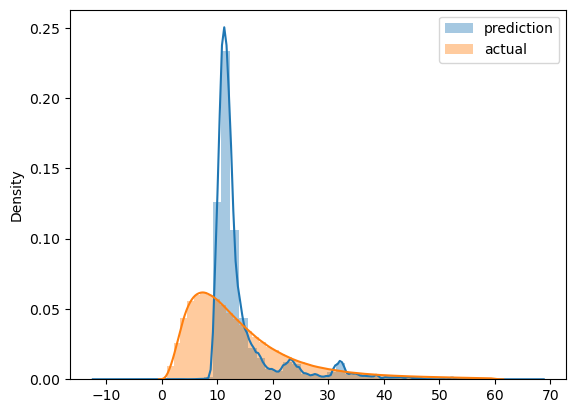

In [13]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [14]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [15]:
df_train = read_dataframe('./data/yellow_tripdata_2023-01.parquet')
df_val = read_dataframe('./data/yellow_tripdata_2023-02.parquet')

In [16]:
len(df_train), len(df_val)

(3009173, 2855951)

In [17]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [18]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [19]:
X_val

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5704693 stored elements and shape (2855951, 21802)>

In [20]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

5.244535975468218

In [22]:
with open('models/lin_reg_homework.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [ ]:
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)